In [1]:
%pip install pandas openpyxl numpy matplotlib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: C:\Users\DELL\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [2]:
import urllib.request
import zipfile
import os

url = "https://archive.ics.uci.edu/static/public/602/dry+bean+dataset.zip"

zip_file = "dry_bean_dataset.zip"

urllib.request.urlretrieve(url, zip_file)

print("Dataset downloaded successfully.")

Dataset downloaded successfully.


In [3]:
with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("dry_bean_data")

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [4]:
os.listdir("dry_bean_data")

['DryBeanDataset']

In [5]:
data_path = "dry_bean_data/DryBeanDataset/Dry_Bean_Dataset.xlsx"

df = pd.read_excel(data_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [6]:
print("Shape of dataset:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

Shape of dataset: (13611, 17)

First 5 rows:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [7]:
print("Columns in the dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(i, ":", column)

Columns in the dataset:

1 : Area
2 : Perimeter
3 : MajorAxisLength
4 : MinorAxisLength
5 : AspectRation
6 : Eccentricity
7 : ConvexArea
8 : EquivDiameter
9 : Extent
10 : Solidity
11 : roundness
12 : Compactness
13 : ShapeFactor1
14 : ShapeFactor2
15 : ShapeFactor3
16 : ShapeFactor4
17 : Class


In [8]:
print("Number of classes:", df["Class"].nunique())

print("\nClass names:")
print(df["Class"].unique())

Number of classes: 7

Class names:
<StringArray>
['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']
Length: 7, dtype: str


In [9]:
missing_values = df.isnull().sum()

print("Missing values in each column:\n")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Total missing values: 0


In [10]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 68


In [11]:
print(df.dtypes)

Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class                  str
dtype: object


In [12]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (13611, 16)
Target shape: (13611,)


In [13]:
print(df.shape)
print(df.columns)
print(df["Class"].value_counts())
print("Duplicates:", df.duplicated().sum())

(13611, 17)
Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4', 'Class'],
      dtype='str')
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64
Duplicates: 68


In [14]:
missing = df.isnull().sum()

print("Missing values in each column:")
print(missing)

print("\nTotal missing values:", missing.sum())

Missing values in each column:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Total missing values: 0


In [15]:
# Check data types
print(df.dtypes)

Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class                  str
dtype: object


In [16]:
# Generate a basic statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860153
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRation,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


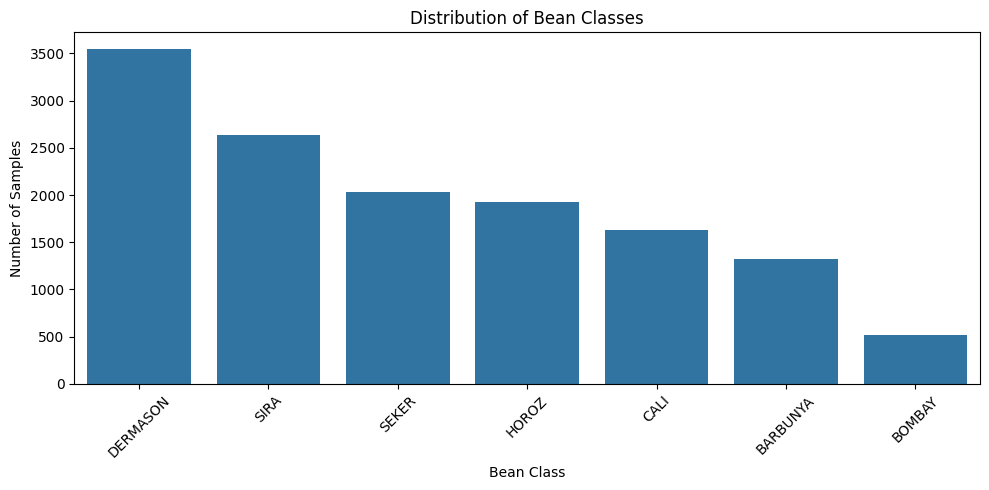

In [17]:
# Check the class distribution visually
# Because this is a multiclass problem, let's create a simple plot.

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Class",
    order=df["Class"].value_counts().index
)

plt.title("Distribution of Bean Classes")
plt.xlabel("Bean Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [18]:
# Let's determine whether these are completely identical records.
duplicate_rows = df[df.duplicated(keep=False)]

print("Total rows involved in duplicate groups:",
      len(duplicate_rows))

display(duplicate_rows.head(10))

Total rows involved in duplicate groups: 136


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
5504,33518,702.956,277.571399,154.305581,1.798842,0.831240,34023,206.582775,0.808383,0.985157,0.852377,0.744251,0.008281,0.001567,0.553909,0.996396,HOROZ
5505,33518,702.956,277.571399,154.305581,1.798842,0.831240,34023,206.582775,0.808383,0.985157,0.852377,0.744251,0.008281,0.001567,0.553909,0.996396,HOROZ
5508,33954,716.750,277.368480,156.356326,1.773951,0.825970,34420,207.922042,0.799482,0.986461,0.830549,0.749624,0.008169,0.001591,0.561936,0.996847,HOROZ
5509,33954,716.750,277.368480,156.356326,1.773951,0.825970,34420,207.922042,0.799482,0.986461,0.830549,0.749624,0.008169,0.001591,0.561936,0.996847,HOROZ
5547,38427,756.323,306.533886,160.591784,1.908777,0.851782,38773,221.193978,0.796976,0.991076,0.844174,0.721597,0.007977,0.001334,0.520702,0.993905,HOROZ
5548,38427,756.323,306.533886,160.591784,1.908777,0.851782,38773,221.193978,0.796976,0.991076,0.844174,0.721597,0.007977,0.001334,0.520702,0.993905,HOROZ
5553,38891,791.343,319.499996,156.869619,2.036723,0.871168,39651,222.525412,0.650025,0.980833,0.780422,0.696480,0.008215,0.001192,0.485085,0.987983,HOROZ
5554,38891,791.343,319.499996,156.869619,2.036723,0.871168,39651,222.525412,0.650025,0.980833,0.780422,0.696480,0.008215,0.001192,0.485085,0.987983,HOROZ
5598,40804,790.802,323.475648,163.287717,1.981016,0.863241,41636,227.932592,0.787570,0.980017,0.819931,0.704636,0.007928,0.001206,0.496512,0.983598,HOROZ
5599,40804,790.802,323.475648,163.287717,1.981016,0.863241,41636,227.932592,0.787570,0.980017,0.819931,0.704636,0.007928,0.001206,0.496512,0.983598,HOROZ


In [19]:
# Now let's check how many duplicate rows belong to each class
print(
    duplicate_rows["Class"].value_counts()
)

Class
HOROZ    136
Name: count, dtype: int64


In [20]:
# Remove exact duplicates
original_size = len(df)

df = df.drop_duplicates().reset_index(drop=True)

new_size = len(df)

print("Original number of rows:", original_size)
print("Rows after removing duplicates:", new_size)
print("Duplicate rows removed:", original_size - new_size)

Original number of rows: 13611
Rows after removing duplicates: 13543
Duplicate rows removed: 68


In [21]:
# Verify the class distribution again
print(df["Class"].value_counts())
print("\nNumber of classes:", df["Class"].nunique())

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Number of classes: 7


In [22]:
# Separate features and target
# Now recreate X and y, because df has changed

X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (13543, 16)
Target shape: (13543,)


In [23]:
#Train/Test Split
# Now we need to divide our data.
# We'll use:
# 80% → training
# 20% → testing
# And importantly, we'll use stratification.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#####################
# Verify the split
#####################

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

###########################
# Verify class proportions
###########################
print("Training class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training set: (10834, 16)
Testing set : (2709, 16)
Training class distribution:
Class
BARBUNYA    0.097563
BOMBAY      0.038582
CALI        0.120362
DERMASON    0.261861
HOROZ       0.137345
SEKER       0.149622
SIRA        0.194665
Name: proportion, dtype: float64

Testing class distribution:
Class
BARBUNYA    0.097822
BOMBAY      0.038391
CALI        0.120340
DERMASON    0.261720
HOROZ       0.137320
SEKER       0.149871
SIRA        0.194537
Name: proportion, dtype: float64


In [24]:
# Step 2 outputs

print("Total missing values:", df.isnull().sum().sum())
print("Rows after removing duplicates:", len(df))
print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)
print(y_train.value_counts(normalize=True).sort_index())
print(y_test.value_counts(normalize=True).sort_index())

Total missing values: 0
Rows after removing duplicates: 13543
Training set: (10834, 16)
Testing set : (2709, 16)
Class
BARBUNYA    0.097563
BOMBAY      0.038582
CALI        0.120362
DERMASON    0.261861
HOROZ       0.137345
SEKER       0.149622
SIRA        0.194665
Name: proportion, dtype: float64
Class
BARBUNYA    0.097822
BOMBAY      0.038391
CALI        0.120340
DERMASON    0.261720
HOROZ       0.137320
SEKER       0.149871
SIRA        0.194537
Name: proportion, dtype: float64


In [25]:
##################################################
# Preprocessing and Model Setup
##################################################

# Import the required libraries

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

In [26]:
###################################
# Create the five model pipelines
###################################

# Logistic Regression
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Decision Tree
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# k-Nearest Neighbors
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(
        n_neighbors=5
    ))
])

# Gaussian Naive Bayes
naive_bayes_model = GaussianNB()

# Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [27]:
##########################################
# Put all five models into a dictionary
##########################################

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "kNN": knn_model,
    "Naive Bayes": naive_bayes_model,
    "Random Forest": random_forest_model
}

print("Models prepared:")
for name in models:
    print("-", name)

Models prepared:
- Logistic Regression
- Decision Tree
- kNN
- Naive Bayes
- Random Forest


In [28]:
####################################
# Before training — verify the data
####################################

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nNumber of models:", len(models))

X_train shape: (10834, 16)
X_test shape : (2709, 16)
y_train shape: (10834,)
y_test shape : (2709,)

Number of models: 5


In [29]:
#############################################
########### Train the five models ###########
#############################################

trained_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[model_name] = model
    print(f"{model_name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
kNN trained successfully.
Naive Bayes trained successfully.
Random Forest trained successfully.


In [30]:
##
# Verify that the models can make predictions
##

predictions = {}

for model_name, model in trained_models.items():
    predictions[model_name] = model.predict(X_test)
    print(f"{model_name}: predictions generated.")

##
# Check one model's predictions
##

print("First 20 actual labels:")
print(y_test.iloc[:20].values)

print("\nFirst 20 Random Forest predictions:")
print(predictions["Random Forest"][:20])

Logistic Regression: predictions generated.
Decision Tree: predictions generated.
kNN: predictions generated.
Naive Bayes: predictions generated.
Random Forest: predictions generated.
First 20 actual labels:
<StringArray>
[   'SEKER', 'DERMASON', 'DERMASON',    'HOROZ',    'SEKER', 'DERMASON',
 'DERMASON', 'DERMASON', 'BARBUNYA', 'DERMASON', 'DERMASON',    'SEKER',
 'DERMASON', 'DERMASON',    'SEKER',     'SIRA',    'HOROZ', 'DERMASON',
 'DERMASON',     'SIRA']
Length: 20, dtype: str

First 20 Random Forest predictions:
['SEKER' 'DERMASON' 'DERMASON' 'HOROZ' 'SEKER' 'DERMASON' 'DERMASON'
 'DERMASON' 'BARBUNYA' 'DERMASON' 'DERMASON' 'SEKER' 'DERMASON' 'DERMASON'
 'SEKER' 'SIRA' 'HOROZ' 'DERMASON' 'DERMASON' 'SIRA']


In [31]:
#####
# Check prediction dimensions
#####

for model_name, pred in predictions.items():
    print(model_name, "→", pred.shape)

Logistic Regression → (2709,)
Decision Tree → (2709,)
kNN → (2709,)
Naive Bayes → (2709,)
Random Forest → (2709,)


In [32]:
########
# Generate prediction probabilities
#########

probabilities = {}

for model_name, model in trained_models.items():
    probabilities[model_name] = model.predict_proba(X_test)
    print(
        f"{model_name}: probability shape = "
        f"{probabilities[model_name].shape}"
    )

Logistic Regression: probability shape = (2709, 7)
Decision Tree: probability shape = (2709, 7)
kNN: probability shape = (2709, 7)
Naive Bayes: probability shape = (2709, 7)
Random Forest: probability shape = (2709, 7)


In [33]:
#########
# Verify probabilities
##########

# Let's inspect the Random Forest probability output.
print(
    pd.DataFrame(
        probabilities["Random Forest"][:5],
        columns=trained_models["Random Forest"].classes_
    )
)

   BARBUNYA  BOMBAY  CALI  DERMASON  HOROZ  SEKER  SIRA
0       0.0     0.0   0.0      0.06    0.0   0.93  0.01
1       0.0     0.0   0.0      1.00    0.0   0.00  0.00
2       0.0     0.0   0.0      1.00    0.0   0.00  0.00
3       0.0     0.0   0.0      0.00    1.0   0.00  0.00
4       0.0     0.0   0.0      0.00    0.0   1.00  0.00


In [34]:
##############################################
############ Evaluation Metrics ##############
##############################################

# Accuracy - Overall percentage of correctly classified observations.
# Precision - We'll use weighted precision, which accounts for the different class sizes.
# Recall - We'll use weighted recall.
# F1 - We'll use weighted F1.
# MCC - MCC supports multiclass classification, so we'll calculate it directly from the multiclass predictions.
# AUC - For our 7-class problem, we'll calculate multiclass ROC-AUC using one-vs-rest (ovr) and weighted averaging.

# Import the evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

In [35]:
######
# Calculate all six metrics
######

# Now we'll create one evaluation loop.

results = []

for model_name in trained_models:

    y_pred = predictions[model_name]
    y_prob = probabilities[model_name]

    accuracy = accuracy_score(y_test, y_pred)

    auc = roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr",
        average="weighted"
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    results.append({
        "ML Model": model_name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "MCC": mcc
    })

print("Evaluation completed for all models.")

Evaluation completed for all models.


In [36]:
######
# Create the comparison table
######

results_df = pd.DataFrame(results)

results_df

,ML Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.919158,0.993449,0.919726,0.919158,0.919290,0.902314
1,Decision Tree,0.895533,0.935674,0.895365,0.895533,0.895289,0.873720
2,kNN,0.915467,0.981051,0.916315,0.915467,0.915652,0.897791
3,Naive Bayes,0.763012,0.964352,0.764673,0.763012,0.760651,0.714296
4,Random Forest,0.916944,0.990544,0.917019,0.916944,0.916887,0.899533


In [37]:
#######
# Format the table for readability
#######

results_display = results_df.copy()

metric_columns = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1",
    "MCC"
]

results_display[metric_columns] = results_display[metric_columns].round(4)

results_display

,ML Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9192,0.9934,0.9197,0.9192,0.9193,0.9023
1,Decision Tree,0.8955,0.9357,0.8954,0.8955,0.8953,0.8737
2,kNN,0.9155,0.9811,0.9163,0.9155,0.9157,0.8978
3,Naive Bayes,0.7630,0.9644,0.7647,0.7630,0.7607,0.7143
4,Random Forest,0.9169,0.9905,0.9170,0.9169,0.9169,0.8995


# Initial observation

## Interestingly, Logistic Regression is currently the overall strongest model.

### It has the highest:

Accuracy → 0.9192
AUC → 0.9934
Precision → 0.9197
Recall → 0.9192
F1 → 0.9193
MCC → 0.9023

In [38]:
############################################################################
############# Confusion Matrices and Classification Reports ################
############################################################################

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Get the class names
class_names = trained_models["Logistic Regression"].classes_

print("Class labels:")
print(class_names)

Class labels:
['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']


In [39]:
#######################################################################
############# Generate confusion matrix for each model ################
#######################################################################

confusion_matrices = {}

for model_name in trained_models:
    cm = confusion_matrix(
        y_test,
        predictions[model_name],
        labels=class_names
    )

    confusion_matrices[model_name] = cm

    print(f"\n{model_name}")
    print(cm)


Logistic Regression
[[236   0  18   0   0   4   7]
 [  0 104   0   0   0   0   0]
 [  8   0 307   0   5   2   4]
 [  0   0   0 643   0  13  53]
 [  1   0  11   5 351   0   4]
 [  9   0   0   5   0 383   9]
 [  1   0   1  41   8  10 466]]

Decision Tree
[[237   0  18   1   0   4   5]
 [  0 104   0   0   0   0   0]
 [ 18   0 297   0   6   2   3]
 [  0   0   0 639   2  11  57]
 [  5   0  12   5 343   0   7]
 [  4   0   1  13   0 380   8]
 [  5   0   4  61   9  22 426]]

kNN
[[232   0  21   0   1   3   8]
 [  0 104   0   0   0   0   0]
 [  8   0 309   0   5   2   2]
 [  0   0   0 647   0  10  52]
 [  0   0  13   4 347   0   8]
 [  6   0   1   7   0 380  12]
 [  3   0   0  49   8   6 461]]

Naive Bayes
[[122   0 108   0  24   0  11]
 [  0 104   0   0   0   0   0]
 [ 42   0 271   0  12   0   1]
 [  0   0   0 584   0  85  40]
 [ 14   0  15   8 295   0  40]
 [  2   0   0  56   6 283  59]
 [  0   0   0  23  41  55 408]]

Random Forest
[[237   0  17   0   1   3   7]
 [  0 104   0   0   0   0   

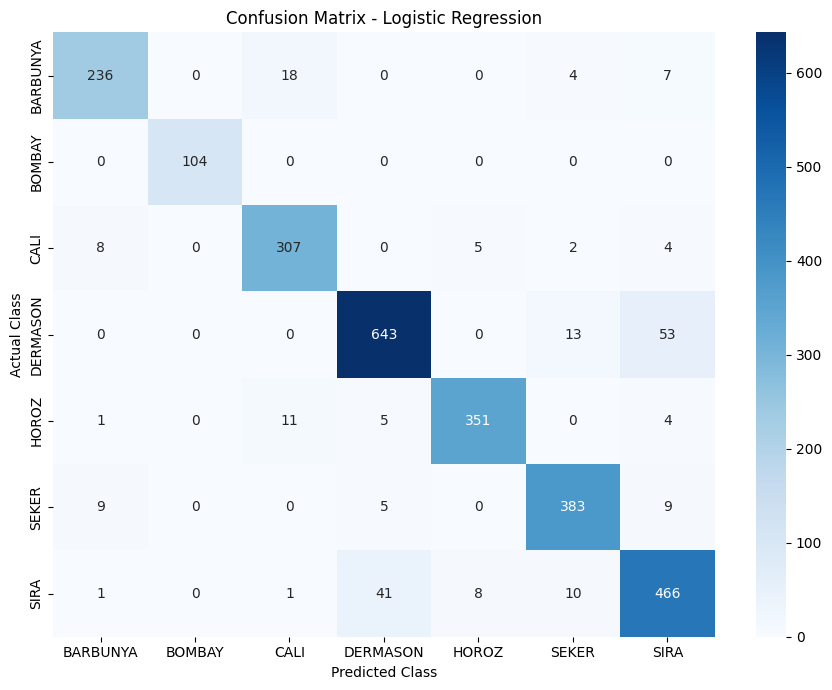

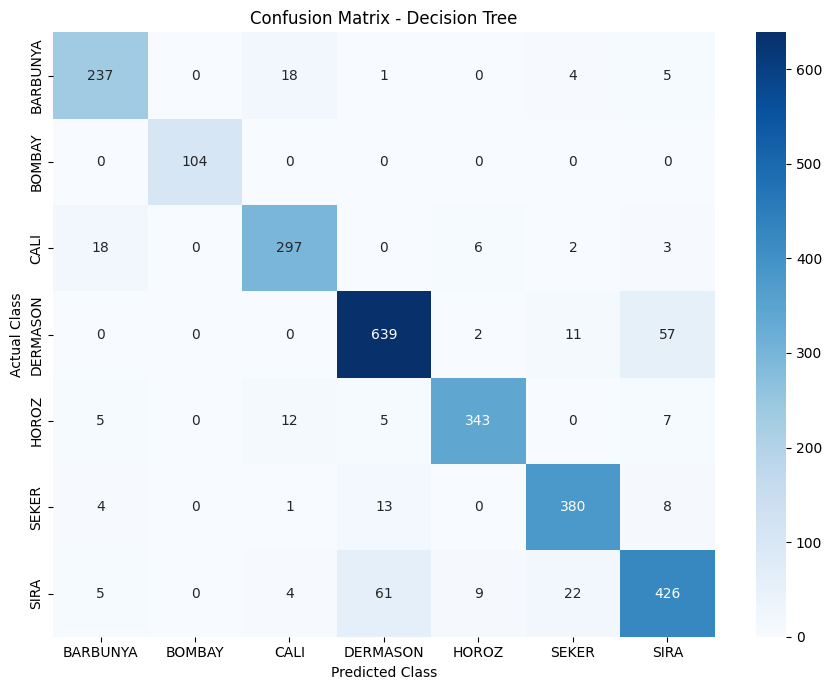

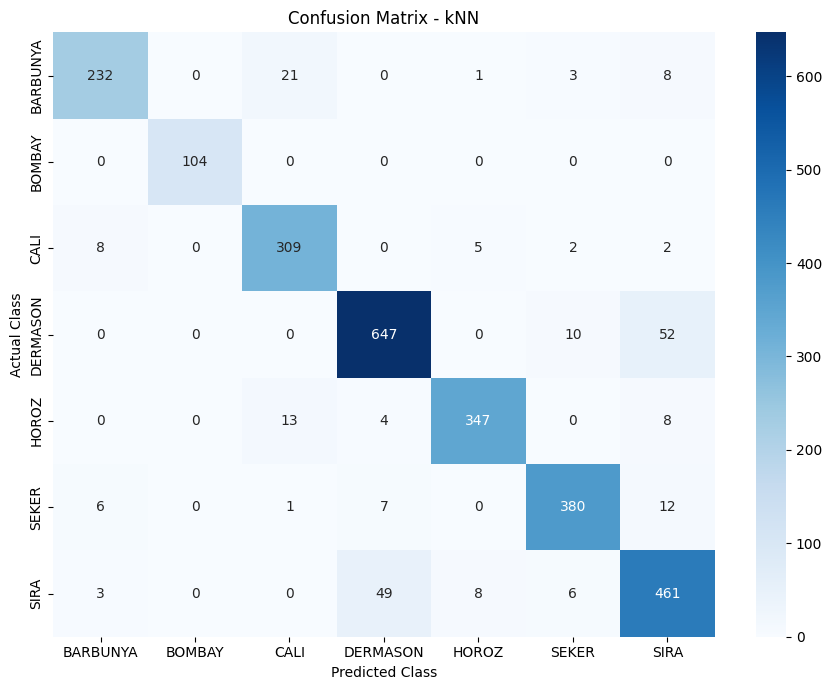

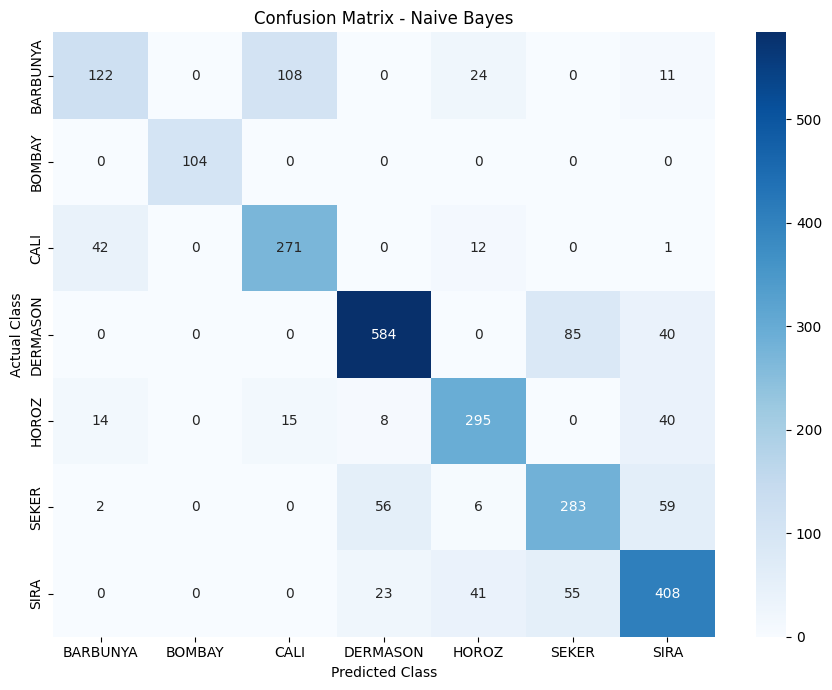

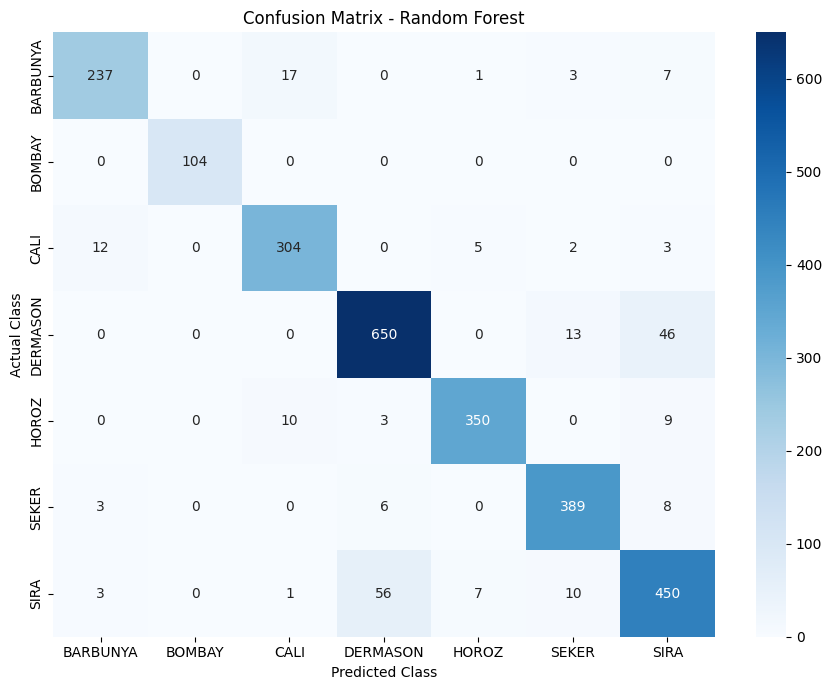

In [41]:
#######################################################################
########### Plot all five models confusion matrix #############
#######################################################################

for model_name, cm in confusion_matrices.items():

    plt.figure(figsize=(9, 7))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.tight_layout()
    plt.show()

In [42]:
#########################################################
########### Generate classification reports #############
#########################################################

classification_reports = {}

for model_name in trained_models:

    report = classification_report(
        y_test,
        predictions[model_name],
        zero_division=0
    )

    classification_reports[model_name] = report

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)
    print(report)


Logistic Regression
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709


Decision Tree
              precision    recall  f1-score   support

    BARBUNYA       0.88      0.89      0.89       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.89      0.91      0.90       326
    DERMASON       0.89      0.90      0.89       709
       HOROZ       0.95      0.92      0.94       372
       SEKER       0.91      0.94      0.9

In [43]:
#####################################################################
########### Generate a compact classification-report table ##########
#####################################################################

# For easier comparison, we can also extract the weighted metrics

report_summary = []

for model_name in trained_models:

    report_dict = classification_report(
        y_test,
        predictions[model_name],
        output_dict=True,
        zero_division=0
    )

    report_summary.append({
        "ML Model": model_name,
        "Weighted Precision": report_dict["weighted avg"]["precision"],
        "Weighted Recall": report_dict["weighted avg"]["recall"],
        "Weighted F1": report_dict["weighted avg"]["f1-score"]
    })

report_summary_df = pd.DataFrame(report_summary)

report_summary_df.round(4)

,ML Model,Weighted Precision,Weighted Recall,Weighted F1
0,Logistic Regression,0.9197,0.9192,0.9193
1,Decision Tree,0.8954,0.8955,0.8953
2,kNN,0.9163,0.9155,0.9157
3,Naive Bayes,0.7647,0.7630,0.7607
4,Random Forest,0.9170,0.9169,0.9169


In [44]:
########################################################################
############## Save the Models and Create test_data.csv ################
########################################################################

import os

os.makedirs("model", exist_ok=True)

print("Model directory is ready.")

Model directory is ready.


In [47]:
#######################################################################
######################## Save all five models #########################
#######################################################################

import pickle

model_file_names = {
    "Logistic Regression": "logistic_regression.pkl",
    "Decision Tree": "decision_tree.pkl",
    "kNN": "knn.pkl",
    "Naive Bayes": "naive_bayes.pkl",
    "Random Forest": "random_forest.pkl"
}

for model_name, file_name in model_file_names.items():

    file_path = os.path.join("model", file_name)

    with open(file_path, "wb") as file:
        pickle.dump(trained_models[model_name], file)

    print(f"{model_name} saved as {file_path}")

# Verify that the .pkl files exist

print("Saved model files:\n")

for file_name in os.listdir("model"):
    print("-", file_name)

# Test that a .pkl file can actually be loaded
with open("model/random_forest.pkl", "rb") as file:
    loaded_rf = pickle.load(file)

rf_test_predictions = loaded_rf.predict(X_test)

print("Loaded model successfully.")
print("Number of predictions:", len(rf_test_predictions))

Logistic Regression saved as model\logistic_regression.pkl
Decision Tree saved as model\decision_tree.pkl
kNN saved as model\knn.pkl
Naive Bayes saved as model\naive_bayes.pkl
Random Forest saved as model\random_forest.pkl
Saved model files:

- decision_tree.pkl
- knn.pkl
- logistic_regression.pkl
- naive_bayes.pkl
- random_forest.pkl
Loaded model successfully.
Number of predictions: 2709


In [51]:
##
# Combine test features and actual labels
##
test_data = X_test.copy()

test_data["Class"] = y_test.values

print("Test data shape:", test_data.shape)

display(test_data.head())

# Save the test data

test_data.to_csv("test_data.csv", index=False)
print("test_data.csv created successfully.")

# Verify the CSV

loaded_test_data = pd.read_csv("test_data.csv")
print("Loaded test CSV shape:", loaded_test_data.shape)
print("\nColumns:")
print(loaded_test_data.columns.tolist())

# Verify that the saved CSV has the correct target distribution
print(loaded_test_data["Class"].value_counts())

# Save the Model Comparison Results
results_df.to_csv("model_comparison.csv", index=False)
print("Model comparison results saved successfully.")

Test data shape: (2709, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
1223,40512,737.636,248.202030,208.525152,1.190274,0.542365,40973,227.115566,0.744268,0.988749,0.935641,0.915043,0.006127,0.002650,0.837304,0.996621,SEKER
11769,31890,660.655,250.417300,162.522502,1.540816,0.760783,32240,201.503372,0.801962,0.989144,0.918153,0.804670,0.007853,0.002031,0.647494,0.997670,DERMASON
12059,33107,671.869,244.728317,172.938116,1.415121,0.707560,33506,205.312303,0.798683,0.988092,0.921638,0.838940,0.007392,0.002259,0.703820,0.995990,DERMASON
7126,61684,984.878,412.115648,191.473280,2.152340,0.885515,62303,280.247227,0.784724,0.990065,0.799130,0.680021,0.006681,0.000881,0.462428,0.995303,HOROZ
638,37189,700.253,243.343401,194.910062,1.248491,0.598708,37534,217.601713,0.784826,0.990808,0.953047,0.894217,0.006543,0.002581,0.799623,0.998322,SEKER


test_data.csv created successfully.
Loaded test CSV shape: (2709, 17)

Columns:
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']
Class
DERMASON    709
SIRA        527
SEKER       406
HOROZ       372
CALI        326
BARBUNYA    265
BOMBAY      104
Name: count, dtype: int64
Model comparison results saved successfully.


In [52]:
print(os.listdir("model"))
print(pd.read_csv("test_data.csv").shape)

['decision_tree.pkl', 'knn.pkl', 'logistic_regression.pkl', 'naive_bayes.pkl', 'random_forest.pkl']
(2709, 17)
